In [1]:
import pysam as os
import json 
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import collections
import re
import seaborn as sns


In [2]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
#with open('/Haplogroups_chrY_Assemblites.txt', 'a+') as file:
#    for x,y in haplogroups.items():
#        file.write(x+"\t"+y+"\n")
#file.close()

In [5]:
def get_attr(attr_string, key):
    for field in attr_string.split(";"):
        if field.startswith(key + "="):
            return field.split("=")[1]
    return None

In [6]:
ampliconicDF1 = pd.read_csv('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/HGSVC3_HPRC_CEPH-AmpliconicGenes_combined_wLiftOff_plusManualAnnotation_nodbGaPSamples.09132025.csv')
ampliconicDF=ampliconicDF1[ampliconicDF1['geneCompletenessInfo']=='Full_Exon_Copy'].copy()

In [7]:
import os
import pandas as pd
import collections
from tqdm import tqdm

compList = []
goodSamples = []
count = 0

directory = '/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/Feyza_gffFiles/'

ampliconicGenesList = ["RBMY", "TSPY", "VCY", "XKRY", "PRY", "HSFY", "DAZ", "CDY", "BPY"]
amp_prefix = tuple(ampliconicGenesList)

def _attr_get(attrs: str, key: str, default=None):
    if not isinstance(attrs, str):
        return default
    needle = key + "="
    if needle not in attrs:
        return default
    return attrs.split(needle, 1)[1].split(";", 1)[0]


allGeneDict = {}  

primary_ampliconic_gene_counts = {}          
primary_ampliconic_family_counts = {}       
primary_ampliconic_gene_counts_by_biotype = {}  
primary_ampliconic_family_counts_by_biotype = {} 

other_ampliconic_gene_counts = {}          
other_ampliconic_family_counts = {}          
other_ampliconic_gene_counts_by_biotype = {}
other_ampliconic_family_counts_by_biotype = {} 

gene_order_by_sample_contig = {}        
gene_order_by_sample_contig_unique = {} 
gene_order_by_biotype_contig = {}      
gene_order_table_contig = {}          

primary_gene_order = {}                
primary_gene_order_unique = {}         
primary_gene_order_table = {}          

def _update_ampliconic_counters(
    *,
    gene_list,
    biotype: str,
    gene_counter: collections.Counter,
    family_counter: collections.Counter,
    gene_by_biotype: dict,
    family_by_biotype: dict,
):
    """Update gene/family counters (and by-biotype versions) from a list of gene names."""
    gene_counter.update(gene_list)

    for g in gene_list:
        g = str(g)
        for fam in ampliconicGenesList:
            if g.startswith(fam):
                family_counter[fam] += 1
                break

    gene_by_biotype.setdefault(biotype, collections.Counter()).update(gene_list)
    for g in gene_list:
        g = str(g)
        for fam in ampliconicGenesList:
            if g.startswith(fam):
                family_by_biotype.setdefault(biotype, collections.Counter())[fam] += 1
                break

def split_ampliconic_per_contig(
    *,
    sample: str,
    contig: str,
    parent_biotype: str,
    tempDF: pd.DataFrame,
    gene_col: str,
    is_primary: bool,
):
    """Create per-contig ampliconic/other lists AND update the appropriate counters."""
    is_amp = tempDF[gene_col].astype(str).str.startswith(amp_prefix, na=False)

    amp_genes = tempDF.loc[is_amp, gene_col].astype(str).tolist()
    oth_genes = tempDF.loc[~is_amp, gene_col].astype(str).tolist()

    allGeneDict[sample][contig][f"{parent_biotype}_ampliconic"] = {"Feyza": amp_genes, "Prajna": "temp"}
    allGeneDict[sample][contig][f"{parent_biotype}_other"]     = {"Feyza": oth_genes, "Prajna": "temp"}

    if is_primary:
        _update_ampliconic_counters(
            gene_list=amp_genes,
            biotype=parent_biotype,
            gene_counter=primary_ampliconic_gene_counts[sample],
            family_counter=primary_ampliconic_family_counts[sample],
            gene_by_biotype=primary_ampliconic_gene_counts_by_biotype[sample],
            family_by_biotype=primary_ampliconic_family_counts_by_biotype[sample],
        )
    else:
        _update_ampliconic_counters(
            gene_list=amp_genes,
            biotype=parent_biotype,
            gene_counter=other_ampliconic_gene_counts[sample][contig],
            family_counter=other_ampliconic_family_counts[sample][contig],
            gene_by_biotype=other_ampliconic_gene_counts_by_biotype[sample][contig],
            family_by_biotype=other_ampliconic_family_counts_by_biotype[sample][contig],
        )

for file in tqdm(os.listdir(directory)):

    if '.DS' in file or 'HG03456' in file or 'NA12884' in file or 'NA12883' in file:
        continue

    count += 1
    sample = str(file.split("_")[0])
    goodSamples.append(sample)
    primary_contig = sample + "_chrY"

    df = pd.read_csv(os.path.join(directory, file), sep='\t', comment='#', header=None)
    df2 = df[df[2] == "gene"].copy()
    attrs = df2[8].astype(str)
    df2["GeneID"]      = attrs.map(lambda x: _attr_get(x, "ID"))
    df2["GeneName"]    = attrs.map(lambda x: _attr_get(x, "gene_name"))
    df2["GeneBiotype"] = attrs.map(lambda x: _attr_get(x, "gene_biotype"))
    df2["coverage"]    = pd.to_numeric(attrs.map(lambda x: _attr_get(x, "coverage")), errors="coerce")
    df2["sequence_ID"] = pd.to_numeric(attrs.map(lambda x: _attr_get(x, "sequence_ID")), errors="coerce")

    df2["start"] = pd.to_numeric(df2[3], errors="coerce")
    df2["end"]   = pd.to_numeric(df2[4], errors="coerce")

    df2 = df2.dropna(subset=["GeneName", "GeneBiotype", "coverage", "sequence_ID", "start", "end"])
    df3 = df2[(df2["coverage"] >= 0.95) & (df2["sequence_ID"] >= 0.95)].copy()
    df3["start_min"] = df3[["start", "end"]].min(axis=1)
    df3["end_max"]   = df3[["start", "end"]].max(axis=1)

    allGeneDict[sample] = {}

    primary_ampliconic_gene_counts[sample] = collections.Counter()
    primary_ampliconic_family_counts[sample] = collections.Counter()
    primary_ampliconic_gene_counts_by_biotype[sample] = {}
    primary_ampliconic_family_counts_by_biotype[sample] = {}

    other_ampliconic_gene_counts[sample] = {}
    other_ampliconic_family_counts[sample] = {}
    other_ampliconic_gene_counts_by_biotype[sample] = {}
    other_ampliconic_family_counts_by_biotype[sample] = {}

    gene_order_by_sample_contig[sample] = {}
    gene_order_by_sample_contig_unique[sample] = {}
    gene_order_by_biotype_contig[sample] = {}
    gene_order_table_contig[sample] = {}


    for contig, subdf in df3.groupby(0, sort=False):
        contig = str(contig)
        is_primary = (contig == primary_contig)

        allGeneDict[sample].setdefault(contig, {})

        if not is_primary:
            other_ampliconic_gene_counts[sample][contig] = collections.Counter()
            other_ampliconic_family_counts[sample][contig] = collections.Counter()
            other_ampliconic_gene_counts_by_biotype[sample][contig] = {}
            other_ampliconic_family_counts_by_biotype[sample][contig] = {}

        sub_sorted = subdf.sort_values(
            by=["start_min", "end_max", "GeneName"],
            ascending=[True, True, True],
            kind="mergesort"
        ).copy()

        ordered = sub_sorted["GeneName"].astype(str).tolist()
        gene_order_by_sample_contig[sample][contig] = ordered

        seen = set()
        uniq = []
        for g in ordered:
            if g not in seen:
                uniq.append(g)
                seen.add(g)
        gene_order_by_sample_contig_unique[sample][contig] = uniq

        gene_order_by_biotype_contig[sample][contig] = {}
        for bt, bt_sub in sub_sorted.groupby("GeneBiotype", sort=False):
            gene_order_by_biotype_contig[sample][contig][bt] = bt_sub["GeneName"].astype(str).tolist()

        gene_order_table_contig[sample][contig] = sub_sorted[[
            0, "start_min", "end_max", "GeneID", "GeneName", "GeneBiotype", "coverage", "sequence_ID"
        ]].rename(columns={0: "contig"})

        for biotype in set(sub_sorted["GeneBiotype"]):
            tempDF = sub_sorted[sub_sorted["GeneBiotype"] == biotype].copy()
            gene_names = tempDF["GeneName"].astype(str).tolist()
            allGeneDict[sample][contig][biotype] = {"Feyza": gene_names, "Prajna": "temp"}

            if biotype in {"protein_coding", "transcribed_pseudogene"}:
                split_ampliconic_per_contig(
                    sample=sample,
                    contig=contig,
                    parent_biotype=biotype,
                    tempDF=tempDF,
                    gene_col="GeneName",
                    is_primary=is_primary,
                )

        countDict = collections.Counter(sub_sorted["GeneBiotype"])
        for key, n in countDict.items():
            compList.append([sample, contig, key, n, "Liftoff"])

    if primary_contig in gene_order_by_sample_contig[sample]:
        primary_gene_order[sample] = gene_order_by_sample_contig[sample][primary_contig]
        primary_gene_order_unique[sample] = gene_order_by_sample_contig_unique[sample][primary_contig]
        primary_gene_order_table[sample] = gene_order_table_contig[sample][primary_contig]
    else:
        primary_gene_order[sample] = []
        primary_gene_order_unique[sample] = []
        primary_gene_order_table[sample] = pd.DataFrame()

print(count)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 143/143 [00:11<00:00, 12.49it/s]

140


In [9]:
import os
import pandas as pd
import collections
from tqdm import tqdm

ampliconicGenesList = ["RBMY", "TSPY", "VCY", "XKRY", "PRY", "HSFY", "DAZ", "CDY", "BPY"]
amp_prefix = tuple(ampliconicGenesList)

primary_ampliconic_gene_counts_Prajna = {}         
primary_ampliconic_family_counts_Prajna = {}        
primary_ampliconic_gene_counts_Prajna_by_biotype = {}   
primary_ampliconic_family_counts_Prajna_by_biotype = {} 

other_ampliconic_gene_counts_Prajna = {}           
other_ampliconic_family_counts_Prajna = {}         
other_ampliconic_gene_counts_Prajna_by_biotype = {} 
other_ampliconic_family_counts_Prajna_by_biotype = {} 

count = 0
samples = []
directory = '/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/gff3/'

def _update_ampliconic_counters(
    *,
    gene_list,
    biotype: str,
    gene_counter: collections.Counter,
    family_counter: collections.Counter,
    gene_by_biotype: dict,
    family_by_biotype: dict,
):
    """Update gene/family counters (and by-biotype) from a list of gene names."""
    gene_counter.update(gene_list)

    for g in gene_list:
        g = str(g)
        for fam in ampliconicGenesList:
            if g.startswith(fam):
                family_counter[fam] += 1
                break

    gene_by_biotype.setdefault(biotype, collections.Counter()).update(gene_list)
    for g in gene_list:
        g = str(g)
        for fam in ampliconicGenesList:
            if g.startswith(fam):
                family_by_biotype.setdefault(biotype, collections.Counter())[fam] += 1
                break

def split_and_count_ampliconic_prajna(
    *,
    sample: str,
    contig: str,
    parent_biotype: str,
    tempDF: pd.DataFrame,
    is_primary: bool,
    gene_col: str = "GeneName",
):
    """Split a biotype into ampliconic vs other and update PRIMARY or OTHER counters (Prajna)."""
    is_amp = tempDF[gene_col].astype(str).str.startswith(amp_prefix, na=False)

    amp_genes = tempDF.loc[is_amp,  gene_col].astype(str).tolist()
    oth_genes = tempDF.loc[~is_amp, gene_col].astype(str).tolist()

    allGeneDict.setdefault(sample, {})
    allGeneDict[sample].setdefault(contig, {})

    allGeneDict[sample][contig].setdefault(f"{parent_biotype}_ampliconic", {})
    allGeneDict[sample][contig][f"{parent_biotype}_ampliconic"].setdefault("Feyza", [])
    allGeneDict[sample][contig][f"{parent_biotype}_ampliconic"]["Prajna"] = amp_genes

    allGeneDict[sample][contig].setdefault(f"{parent_biotype}_other", {})
    allGeneDict[sample][contig][f"{parent_biotype}_other"].setdefault("Feyza", [])
    allGeneDict[sample][contig][f"{parent_biotype}_other"]["Prajna"] = oth_genes

    if is_primary:
        _update_ampliconic_counters(
            gene_list=amp_genes,
            biotype=parent_biotype,
            gene_counter=primary_ampliconic_gene_counts_Prajna[sample],
            family_counter=primary_ampliconic_family_counts_Prajna[sample],
            gene_by_biotype=primary_ampliconic_gene_counts_Prajna_by_biotype[sample],
            family_by_biotype=primary_ampliconic_family_counts_Prajna_by_biotype[sample],
        )
    else:
        _update_ampliconic_counters(
            gene_list=amp_genes,
            biotype=parent_biotype,
            gene_counter=other_ampliconic_gene_counts_Prajna[sample][contig],
            family_counter=other_ampliconic_family_counts_Prajna[sample][contig],
            gene_by_biotype=other_ampliconic_gene_counts_Prajna_by_biotype[sample][contig],
            family_by_biotype=other_ampliconic_family_counts_Prajna_by_biotype[sample][contig],
        )

for file in tqdm(os.listdir(directory)):
    if ('.DS' in file) or ('HG03456' in file) or ('NA12884' in file) or ('NA12883' in file):
        continue

    count += 1
    sample = str(file.split("_")[0])
    primary_contig = sample + "_chrY"

    df = pd.read_csv(os.path.join(directory, file), sep='\t', comment='#', header=None)
    df2 = df[df[2] == 'gene'].copy()

    gene_name = df2[8].str.extract(r'gene_name=([^;]+)', expand=False)
    name_attr = df2[8].str.extract(r'Name=([^;]+)', expand=False)

    df2["GeneName"]    = gene_name.fillna(name_attr).fillna(name_attr).astype(str)
    df2["GeneName2"]   = name_attr
    df2["Orig_GeneBiotype"] = df2[8].str.extract(r'gene_biotype=([^;]+)', expand=False)

    changeBioDict={'lncRNA':'lncRNA',
                 'miRNA':'miRNA',
                 'misc_RNA':'misc_RNA',
                 'processed_pseudogene':'pseudogene',
                 'protein_coding':'protein_coding',
                 'rRNA_pseudogene':'pseudogene',
                 'snRNA':'snRNA',
                 'snoRNA':'snoRNA',
                 'transcribed_processed_pseudogene':'transcribed_pseudogene',
                 'transcribed_unitary_pseudogene':'transcribed_pseudogene',
                 'transcribed_unprocessed_pseudogene':'transcribed_pseudogene',
                 'unprocessed_pseudogene':'pseudogene'
                }
    df2["GeneBiotype"]=[changeBioDict[x] for x in df2["Orig_GeneBiotype"]]

    allGeneDict.setdefault(sample, {})
    primary_ampliconic_gene_counts_Prajna[sample] = collections.Counter()
    primary_ampliconic_family_counts_Prajna[sample] = collections.Counter()
    primary_ampliconic_gene_counts_Prajna_by_biotype[sample] = {}
    primary_ampliconic_family_counts_Prajna_by_biotype[sample] = {}

    other_ampliconic_gene_counts_Prajna[sample] = {}
    other_ampliconic_family_counts_Prajna[sample] = {}
    other_ampliconic_gene_counts_Prajna_by_biotype[sample] = {}
    other_ampliconic_family_counts_Prajna_by_biotype[sample] = {}

    for contig, subdf in df2.groupby(0, sort=False):
        contig = str(contig)
        is_primary = (contig == primary_contig)

        allGeneDict[sample].setdefault(contig, {})

        if not is_primary:
            other_ampliconic_gene_counts_Prajna[sample][contig] = collections.Counter()
            other_ampliconic_family_counts_Prajna[sample][contig] = collections.Counter()
            other_ampliconic_gene_counts_Prajna_by_biotype[sample][contig] = {}
            other_ampliconic_family_counts_Prajna_by_biotype[sample][contig] = {}

        countDict = collections.Counter(subdf["GeneBiotype"].dropna())
        for bt, n in countDict.items():
            compList.append([sample, contig, bt, n, 'Pangenome'])

        for biotype in set(subdf["GeneBiotype"].dropna()):
            tempDF = subdf[subdf["GeneBiotype"] == biotype].copy()

            allGeneDict[sample][contig].setdefault(biotype, {})
            allGeneDict[sample][contig][biotype].setdefault("Feyza", [])
            allGeneDict[sample][contig][biotype]["Prajna"] = tempDF["GeneName"].tolist()

            if biotype in {"protein_coding", "transcribed_pseudogene"}:
                split_and_count_ampliconic_prajna(
                    sample=sample,
                    contig=contig,
                    parent_biotype=biotype,
                    tempDF=tempDF,
                    is_primary=is_primary,
                    gene_col="GeneName",
                )

    samples.append(sample)

print(count)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 141/141 [00:11<00:00, 11.94it/s]

140


In [11]:
import numpy as np
import pandas as pd

def build_consensus_gene_order(
    gene_order_table_contig: dict,
    *,
    primary_contig_suffix: str = "_chrY",
    use_primary_only: bool = True,     
    include_other_contigs: bool = False, 
    biotype_filter: set | None = None,   
    use_unique_per_sample: bool = True, 
    prefer_earliest_copy: bool = True, 
    min_samples: int = 1                
):
    """
    Builds a consensus gene order across samples by averaging within-sample ranks.

    Expected input:
        gene_order_table_contig[sample][contig] -> DataFrame with columns:
            contig, start_min, end_max, GeneID, GeneName, GeneBiotype, coverage, sequence_ID

    Primary behavior (recommended):
        - Use only primary contig (sample + primary_contig_suffix) unless include_other_contigs is enabled.
        - Ranks are computed within the chosen contig table(s).
        - If include_other_contigs=True, we keep contig-specific consensus separately.

    Returns:
      If use_primary_only (default):
        summary_df, consensus_gene_order
      If include_other_contigs=True:
        {contig_key: (summary_df, consensus_gene_order)} where contig_key is "PRIMARY" or contig name
    """
    def _one_table_to_rows(sample: str, tab: pd.DataFrame, contig_key: str):
        df = tab.copy()

        if biotype_filter is not None and "GeneBiotype" in df.columns:
            df = df[df["GeneBiotype"].isin(biotype_filter)].copy()

        df = df.reset_index(drop=True)
        df["rank"] = np.arange(1, len(df) + 1)

        if use_unique_per_sample:
            if prefer_earliest_copy:
                df = df.sort_values(["rank"], kind="mergesort").drop_duplicates("GeneName", keep="first")
            else:
                df = df.groupby("GeneName", as_index=False)["rank"].mean()

        out = []
        for _, r in df.iterrows():
            out.append([sample, contig_key, str(r["GeneName"]), float(r["rank"])])
        return out


    rows = []

    for sample, contig_map in gene_order_table_contig.items():
        if not isinstance(contig_map, dict):
            rows.extend(_one_table_to_rows(sample, contig_map, "PRIMARY"))
            continue

        primary_contig = f"{sample}{primary_contig_suffix}"

        if use_primary_only:
            tab = contig_map.get(primary_contig)
            if tab is not None and isinstance(tab, pd.DataFrame) and len(tab) > 0:
                rows.extend(_one_table_to_rows(sample, tab, "PRIMARY"))
        else:
            tab = contig_map.get(primary_contig)
            if tab is not None and isinstance(tab, pd.DataFrame) and len(tab) > 0:
                rows.extend(_one_table_to_rows(sample, tab, "PRIMARY"))

        if include_other_contigs:
            for contig, tab in contig_map.items():
                contig = str(contig)
                if contig == primary_contig:
                    continue
                if tab is None or (not isinstance(tab, pd.DataFrame)) or len(tab) == 0:
                    continue
                rows.extend(_one_table_to_rows(sample, tab, contig_key=contig))

    ranks = pd.DataFrame(rows, columns=["sample", "contig", "GeneName", "rank"])

    if ranks.empty:
        empty = pd.DataFrame(columns=["GeneName", "mean_rank", "median_rank", "sd_rank", "n_samples"])
        return empty, []

    def _summarize(sub: pd.DataFrame):
        summary = (
            sub.groupby("GeneName")
            .agg(
                mean_rank=("rank", "mean"),
                median_rank=("rank", "median"),
                sd_rank=("rank", "std"),
                n_samples=("sample", "nunique"),
            )
            .reset_index()
        )
        summary = summary[summary["n_samples"] >= min_samples].copy()
        summary = summary.sort_values(["mean_rank", "median_rank", "sd_rank", "GeneName"], kind="mergesort")
        return summary, summary["GeneName"].tolist()


    if include_other_contigs:
        out = {}
        for contig_key, sub in ranks.groupby("contig", sort=False):
            out[str(contig_key)] = _summarize(sub)
        return out 

    primary_rows = ranks[ranks["contig"] == "PRIMARY"].copy()
    return _summarize(primary_rows)


consensus_order_df, consensus_gene_order = build_consensus_gene_order(
    gene_order_table_contig,   
    biotype_filter=None,
    use_unique_per_sample=True,
    prefer_earliest_copy=True,
    min_samples=1,
    use_primary_only=True,
    include_other_contigs=False
)

## Compare Callers

In [13]:
from collections import Counter
import pandas as pd

def compare_multiset_lists_contig(
    d,
    key_a="Feyza",
    key_b="Prajna",
    *,
    primary_contig_suffix="_chrY",
    use_primary_only=True,
    include_other_contigs=False,
    sort=True,
):
    """
    Compare multiset gene lists between two callers (A vs B) WITHOUT merging contigs.

    Expected input (NEW):
        d[sample][contig][biotype_or_splitkey] -> {"Feyza": [...], "Prajna": [...]}

    By default:
        - compares only the primary contig sample + primary_contig_suffix
        - keeps duplicates (multiset behavior)

    Returns:
        out: nested dict out[sample][contig][biotype] -> comparison details
        df : tidy DataFrame with one row per (sample, contig, biotype)
    """
    rows = []
    out = {}

    for sample, contig_map in d.items():
        if not isinstance(contig_map, dict):
            continue

        primary_contig = f"{sample}{primary_contig_suffix}"
        contigs_to_use = []
        if use_primary_only:
            if primary_contig in contig_map:
                contigs_to_use = [primary_contig]
        else:
            if primary_contig in contig_map:
                contigs_to_use.append(primary_contig)

        if include_other_contigs:
            for c in contig_map.keys():
                if c != primary_contig:
                    contigs_to_use.append(c)

        if not contigs_to_use:
            continue

        out.setdefault(sample, {})

        for contig in contigs_to_use:
            biotype_map = contig_map.get(contig, {})
            if not isinstance(biotype_map, dict):
                continue

            out[sample].setdefault(contig, {})

            for biotype, comp_map in biotype_map.items():
                if not isinstance(comp_map, dict):
                    continue

                a = comp_map.get(key_a, []) or []
                b = comp_map.get(key_b, []) or []

                ca = Counter(a)
                cb = Counter(b)

                shared = {g: min(ca[g], cb[g]) for g in (ca.keys() | cb.keys()) if min(ca[g], cb[g]) > 0}
                only_a = {g: ca[g] - cb.get(g, 0) for g in ca if ca[g] - cb.get(g, 0) > 0}
                only_b = {g: cb[g] - ca.get(g, 0) for g in cb if cb[g] - ca.get(g, 0) > 0}

                if sort:
                    only_a = dict(sorted(only_a.items()))
                    only_b = dict(sorted(only_b.items()))
                    shared = dict(sorted(shared.items()))

                out[sample][contig][biotype] = {
                    f"counts_{key_a}": dict(ca),
                    f"counts_{key_b}": dict(cb),
                    f"unique_to_{key_a}": only_a, 
                    f"unique_to_{key_b}": only_b,  
                    "shared": shared,         
                    f"total_{key_a}": sum(ca.values()),
                    f"total_{key_b}": sum(cb.values()),
                }

                rows.append({
                    "Sample": sample,
                    "Contig": contig,
                    "IsPrimary": (contig == primary_contig),
                    "Biotype": biotype,
                    f"total_{key_a}": sum(ca.values()),
                    f"total_{key_b}": sum(cb.values()),
                    f"n_unique_copies_{key_a}": sum(only_a.values()),
                    f"n_unique_copies_{key_b}": sum(only_b.values()),
                    "n_shared_copies": sum(shared.values()),
                    f"unique_to_{key_a}": only_a,
                    f"unique_to_{key_b}": only_b,
                    "shared": shared,
                })

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["Sample", "IsPrimary", "Contig", "Biotype"], ascending=[True, False, True, True]).reset_index(drop=True)

    return out, df

In [14]:
summary_dict, diff_df = compare_multiset_lists_contig(
    allGeneDict,
    key_a="Feyza",
    key_b="Prajna",
    use_primary_only=True,
    include_other_contigs=True,
)

In [15]:
import collections

ampliconic_family_counts_Mark = {}
diff_df["total_Mark"] = 0

primary_sub = ampliconicDF[ampliconicDF["contig"] == ampliconicDF["sampleName"] + "_chrY"].copy()

primary_counts_by_sample = {
    s: collections.Counter(g["geneName"])
    for s, g in primary_sub.groupby("sampleName", sort=False)
}

primary_total_excl_xkry = (
    primary_sub[primary_sub["geneName"] != "XKRY"]
    .groupby("sampleName")["geneName"]
    .size()
    .to_dict()
)
primary_total_only_xkry = (
    primary_sub[primary_sub["geneName"] == "XKRY"]
    .groupby("sampleName")["geneName"]
    .size()
    .to_dict()
)

for row in diff_df.index:
    biotype = diff_df.at[row, "Biotype"]
    if biotype not in {"protein_coding_ampliconic", "transcribed_pseudogene_ampliconic"}:
        continue

    sample = diff_df.at[row, "Sample"]
    c = primary_counts_by_sample.get(sample, collections.Counter())

    if biotype == "protein_coding_ampliconic":
        ampliconic_family_counts_Mark[sample] = c
        diff_df.at[row, "total_Mark"] = int(primary_total_excl_xkry.get(sample, 0))

    elif biotype == "transcribed_pseudogene_ampliconic":
        ampliconic_family_counts_Mark[sample] = {k: v for k, v in c.items() if k == "XKRY"}
        diff_df.at[row, "total_Mark"] = int(primary_total_only_xkry.get(sample, 0))


In [18]:
sum(diff_df.at[0,'unique_to_Prajna'].values())

171

In [19]:
goodTogoDF = diff_df[['Sample','Contig','Biotype','total_Feyza','total_Prajna','n_unique_copies_Feyza','n_unique_copies_Prajna','n_shared_copies','unique_to_Feyza','unique_to_Prajna','shared']].copy()

In [20]:
target = {'e': 1, 'm': 1, 'p': 1, 't': 1}

goodTogoDF["unique_to_Prajna"] = goodTogoDF["unique_to_Prajna"].apply(
    lambda x: {} if isinstance(x, dict) and x == target else x
)
goodTogoDF["unique_to_Feyza"] = goodTogoDF["unique_to_Feyza"].apply(
    lambda x: {} if isinstance(x, dict) and x == target else x
)
goodTogoDF['total_Prajna'] =  [sum(x.values()) + sum(y.values()) for x,y in zip(goodTogoDF['unique_to_Prajna'],goodTogoDF['shared'])]
goodTogoDF['n_unique_copies_Prajna'] =  [sum(x.values()) for x in goodTogoDF['unique_to_Prajna']]

In [21]:
goodTogoDF.set_index('Sample').to_csv("/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/Liftoff_Pangenome_Summary_Genes.03102026.csv")

In [22]:
len(diff_df.at[0,'unique_to_Prajna'].keys())

141

In [23]:
len([x for x in diff_df.at[0,'shared'].keys()])

49

In [24]:
proteinCodingOtherDF = goodTogoDF[goodTogoDF['Biotype']=='protein_coding_other'].copy()
proteinCodingOtherDF2=proteinCodingOtherDF[~proteinCodingOtherDF['Contig'].str.contains("random", regex=True)].copy()

In [25]:
proteinCodingAmpliconic = goodTogoDF[goodTogoDF['Biotype']=='protein_coding_ampliconic'].copy()
proteinCodingAmpliconic2 = proteinCodingAmpliconic[~proteinCodingAmpliconic['Contig'].str.contains("random", regex=True)].copy()

In [26]:
print(np.mean(proteinCodingOtherDF2['total_Feyza']))
print(np.mean(proteinCodingOtherDF2['total_Prajna']))

35.55
32.91428571428571


In [27]:
print(np.median(proteinCodingOtherDF2['total_Feyza']))
print(np.median(proteinCodingOtherDF2['total_Prajna']))

36.0
33.0


In [28]:
mainContigGTG = goodTogoDF[~goodTogoDF['Contig'].str.contains("random", regex=True)].copy()

In [25]:
import pandas as pd

def extract_gff3_attributes(
    df,
    attribute_col=8,
    attributes_to_extract=None,
    prefix=None
):

    if attributes_to_extract is not None:
        attributes_to_extract = set(attributes_to_extract)

    def parse_attributes(attr_string):
        parsed = {}

        if pd.isna(attr_string):
            return parsed

        fields = str(attr_string).split(";")

        for field in fields:
            if "=" not in field:
                continue

            key, value = field.split("=", 1)

            if attributes_to_extract is None or key in attributes_to_extract:
                colname = f"{prefix}_{key}" if prefix else key
                parsed[colname] = value

        return parsed

    attr_df = df[attribute_col].apply(parse_attributes).apply(pd.Series)
    out_df = pd.concat([df, attr_df], axis=1)

    return out_df


In [26]:
gencode1 = pd.read_csv("/LeeLab/HPRC/chromosomeY/Information/GENCODE/gencode.v49.annotation.gff3", comment='#',sep='\t', header=None)
gencodechrY = extract_gff3_attributes(gencode1[(gencode1[0]=='chrY') & (gencode1[2]=='gene')])
gencodechrX = extract_gff3_attributes(gencode1[(gencode1[0]=='chrX')& (gencode1[2]=='gene')])
allGencode = extract_gff3_attributes(gencode1[(gencode1[2]=='gene')].copy())
geneChromosomes ={x:y for x,y in zip(allGencode['gene_name'],allGencode[0])}

In [27]:
weirdGeneList=[]
for row in mainContigGTG.index:
    contig = mainContigGTG.at[row, 'Contig']
    biotype = mainContigGTG.at[row, 'Biotype']

    if 'other' in biotype:
        continue
    else:
        liftoffGenes = mainContigGTG.at[row, 'unique_to_Feyza']
        graphGenes = mainContigGTG.at[row, 'unique_to_Prajna']
        sharedGenes = mainContigGTG.at[row, 'shared']
    
        for gene,count in liftoffGenes.items():
            if gene in geneChromosomes:
                if geneChromosomes[gene] =='chrY':
                    continue
                else:
                    weirdGeneList.append([biotype,contig.split("_")[0], contig,row, 'liftoff', gene+"_"+geneChromosomes[gene], geneChromosomes[gene]])
    
        for gene,count in graphGenes.items():
            if gene in geneChromosomes:
                if geneChromosomes[gene] =='chrY':
                    continue
                else:
                    weirdGeneList.append([biotype,contig.split("_")[0],contig,row, 'Pangenome Graph', gene+"_"+geneChromosomes[gene], geneChromosomes[gene]])
    
        for gene,count in sharedGenes.items():
            if gene in geneChromosomes:
                if geneChromosomes[gene] =='chrY':
                    continue
                else:
                    weirdGeneList.append([biotype,contig.split("_")[0], contig,row, 'Shared call', gene+"_"+geneChromosomes[gene], geneChromosomes[gene]]) 

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

weirdDF = pd.DataFrame(data=weirdGeneList)

weirdDF.columns = ["biotype","sample","contig","index","caller","gene","chrom"]
weirdDF['Haplotype']=[haplogroups[x] for x in weirdDF['sample']]
weirdDF["sample"] = pd.Categorical(
    weirdDF["sample"],
    categories=phylogeneticOrder,
    ordered=True
)

weirdDF = weirdDF.sort_values("sample")


sample_hap_map = (
    weirdDF[["sample", "Haplotype"]]
    .drop_duplicates()
    .set_index("sample")["Haplotype"]
)

heatmap_df = (
    weirdDF.assign(value=1)
      .pivot_table(
          index="sample",
          columns="gene",
          values="value",
          fill_value=0
      )
)

heatmap_df = heatmap_df.reindex(phylogeneticOrder)
new_labels = [
    f"{sample}\n{sample_hap_map.get(sample, '')}"
    for sample in heatmap_df.index
]

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_72560/521290412.py:26: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  .pivot_table(


In [44]:
weirdDF.to_csv("/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/nonY_GeneList.csv")

In [41]:
len(set(weirdDF['gene']))

21

In [39]:
706/797

0.8858218318695107

In [36]:
collections.Counter(weirdDF['chrom'])

Counter({'chrX': 280,
         'chr15': 181,
         'chr3': 140,
         'chr16': 105,
         'chr1': 29,
         'chr4': 24,
         'chr2': 12,
         'chr19': 9,
         'chr20': 6,
         'chr7': 4,
         'chr9': 3,
         'chr10': 3,
         'chr14': 1})

In [38]:
105+140+181+280

706

In [33]:
np.mean([int(x) for x in collections.Counter(weirdDF['sample']).values()])

np.float64(5.692857142857143)

In [34]:
len(collections.Counter(weirdDF['sample']))

140

In [30]:
weirdDF['Haplogroup']=[x[0] for x in weirdDF['Haplotype']]
to_drop = {"NA12883", "NA12884"}

phylo_present = [s for s in phylogeneticOrder if (s in heatmap_df.index) and (s not in to_drop)]

heatmap_df_plot = heatmap_df.loc[phylo_present].copy()

In [31]:
from scipy.stats import fisher_exact
import pandas as pd

results = []

for gene in heatmap_df_plot.columns:

    for hap in weirdDF["Haplotype"].unique():

        samples_in = sample_hap_map[sample_hap_map == hap].index
        samples_out = sample_hap_map[sample_hap_map != hap].index

        a = heatmap_df_plot.loc[samples_in, gene].sum()
        b = heatmap_df_plot.loc[samples_out, gene].sum()

        c = len(samples_in) - a
        d = len(samples_out) - b

        table = [[a, b], [c, d]]

        _, p = fisher_exact(table)

        results.append({
            "gene": gene,
            "Haplotype": hap,
            "pvalue": p,
            "present_in_hap": a,
            "present_outside": b
        })

results_df = pd.DataFrame(results)

In [32]:
from statsmodels.stats.multitest import multipletests

results_df["FDR"] = multipletests(results_df["pvalue"], method="fdr_bh")[1]

In [33]:
results_df[results_df['FDR']<0.05]

,gene,Haplotype,pvalue,present_in_hap,present_outside,FDR
198,CICP9_chr10,A1a,0.000002,3.0,0.0,0.004598


In [40]:
results_df

NameError: name 'results_df' is not defined

In [34]:
subset_genes = {}

for hap in set(weirdDF["Haplogroup"]):

    samples = list(set(weirdDF[weirdDF["Haplogroup"]==hap]['sample']))

    present = heatmap_df_plot.loc[samples].sum()
    outside = heatmap_df_plot.drop(samples).sum()

    unique_genes = present[(present > 0) & (outside == 0)].index.tolist()

    subset_genes[hap] = unique_genes

In [ ]:
A: CICP9_chr10; C: SEPTIN14P17_chr1; B:RNU6-689P_chr14; E:CICP19_chr19,SEPTIN14P2_chr2; N:GYG2_chrX

In [35]:
subset_genes

{'I': [],
 'A': ['CICP9_chr10'],
 'D': ['DDX11L9_chr15'],
 'T': [],
 'C': ['SEPTIN14P17_chr1'],
 'B': ['RNU6-689P_chr14'],
 'E': ['CICP19_chr19', 'SEPTIN14P2_chr2'],
 'H': [],
 'F': [],
 'J': [],
 'L': [],
 'Q': [],
 'R': [],
 'N': ['GYG2_chrX'],
 'G': [],
 'O': []}

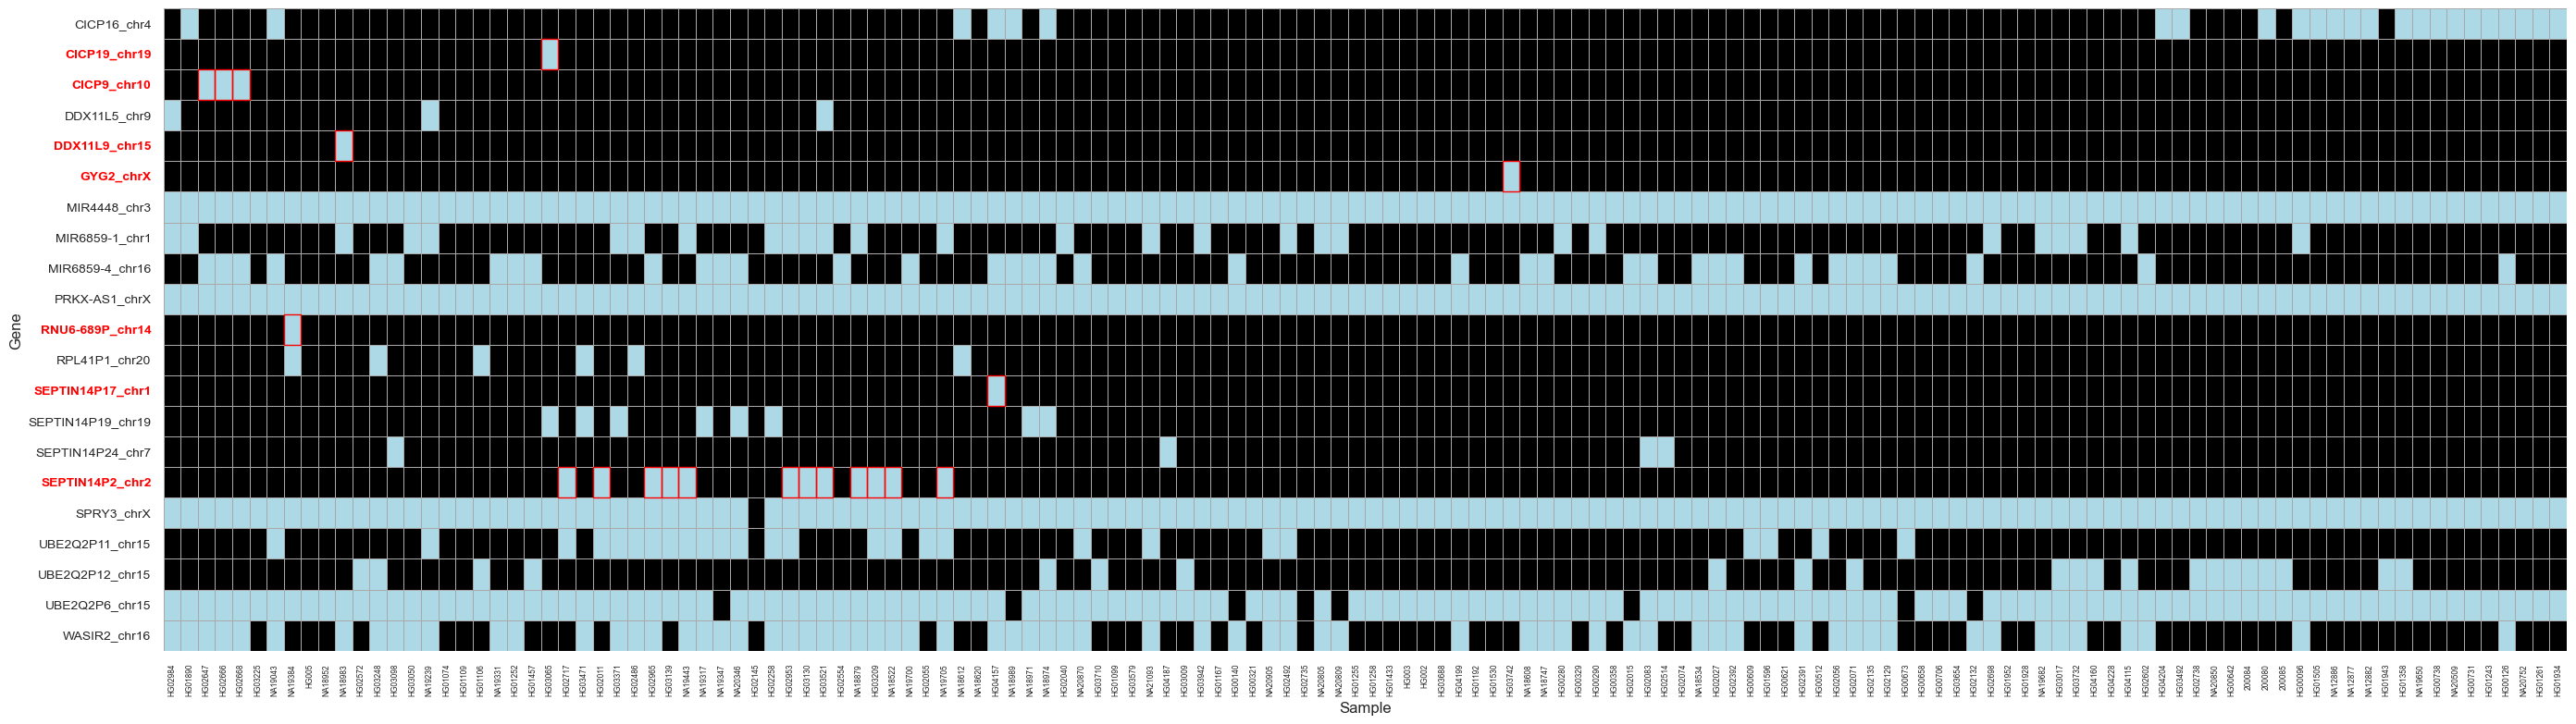

In [98]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

to_drop = {"NA12883", "NA12884"}

phylo_present = [s for s in phylogeneticOrder if (s in heatmap_df.index) and (s not in to_drop)]

heatmap_df_plot = heatmap_df.loc[phylo_present].copy()

plt.figure(figsize=(28, 8))

ax = sns.heatmap(
    heatmap_df_plot.T,   
    cmap=["black", "lightblue"],
    linewidths=0.5,
    linecolor="darkgrey",
    cbar=None,
)

ax.set_yticklabels(heatmap_df_plot.columns, rotation=0, fontsize=10)
ax.set_xticklabels(heatmap_df_plot.index, rotation=90, fontsize=6)
y_offset = -0.45

for major_hap, genes in subset_genes.items():
    if not genes:
        continue

    hap_samples = sample_major_hap[sample_major_hap == major_hap].index
    hap_samples = [s for s in hap_samples if s in heatmap_df_plot.index]

    for gene in genes:
        if gene not in heatmap_df_plot.columns:
            continue

        row = heatmap_df_plot.columns.get_loc(gene)

        for sample in hap_samples:
            col = heatmap_df_plot.index.get_loc(sample)

            if heatmap_df_plot.loc[sample, gene] != 1:
                continue

            ax.add_patch(
                patches.Rectangle(
                    (col, row), 1, 1,
                    fill=False,
                    edgecolor="red",
                    linewidth=1,
                    zorder=10
                )
            )

highlight_gene_set = {g for genes in subset_genes.values() for g in genes}

for tick in ax.get_yticklabels():
    if tick.get_text() in highlight_gene_set:
        tick.set_color("red")
        tick.set_fontweight("bold")

plt.xlabel("Sample")
plt.ylabel("Gene")

plt.tight_layout()

plt.savefig(
    "/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/GenesFromOtherChromosomes_heatmap.03102026.jpeg",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/GenesFromOtherChromosomes_heatmap.03102026.pdf",
    bbox_inches="tight"
)

plt.show()

## Done Combining

In [70]:
pcgchrY_GENCODE=['AKAP17A',
 'AMELY',
 'ASMT',
 'ASMTL',
 'CD99',
 'CRLF2',
 'CSF2RA',
 'DDX3Y',
 'DHRSX',
 'EIF1AY',
 'GTPBP6',
 'IL3RA',
 'IL9R',
 'KDM5D',
 'NLGN4Y',
 'P2RY8',
 'PCDH11Y',
 'PLCXD1',
 'PPP2R3B',
 'RPS4Y1',
 'RPS4Y2',
 'SHOX',
 'SLC25A6',
 'SRY',
 'TBL1Y',
 'TGIF2LY',
 'TMSB4Y',
 'USP9Y',
 'UTY',
 'VAMP7',
 'WASH6P',
 'ZBED1',
 'ZFY']

In [71]:
uniqueProteinCoding = diff_df[diff_df['Biotype']=='protein_coding_other'].copy()

In [72]:
#just used for checks
#prajnadirectory = '/LeeLab/HPRC/chromosomeY/Data/geneAnnotation/gff3/'
#prajnaDF = pd.read_csv(prajnadirectory+"HG00738_chrY_consensus.gff3", sep='\t', comment='#', header=None)
#prajnaDF2=prajnaDF[prajnaDF[2]=='gene'].copy()
#prajnaDF2[prajnaDF2[8].str.contains("GTPBP6", regex=True)]

In [73]:
uniqueGeneNames=[]
for dictionary in uniqueProteinCoding['unique_to_Feyza']:
    for name in dictionary.keys():
        uniqueGeneNames.append(name)

for dictionary in uniqueProteinCoding['unique_to_Prajna']:
    for name in dictionary.keys():
        uniqueGeneNames.append(name)

for dictionary in uniqueProteinCoding['shared']:
    for name in dictionary.keys():
        uniqueGeneNames.append(name)

In [41]:
uniqueNames = [x for x in collections.Counter(uniqueGeneNames).keys() if x in pcgchrY_GENCODE]

In [42]:
#THIS IS A PRESENCE ABSENCE HEATMAP
uniqueProteinCoding2 = uniqueProteinCoding[uniqueProteinCoding['IsPrimary']==True].copy()
sampleList = set(uniqueProteinCoding2['Sample'])
uniqProGenes = pd.DataFrame(0, columns=uniqueNames, index=[x for x in phylogeneticOrder if x in sampleList])

for sample, dictionary in zip(uniqueProteinCoding2['Sample'], uniqueProteinCoding2['unique_to_Feyza']):
    for name,count in dictionary.items():
        if name in uniqueNames:
            uniqProGenes.at[sample,name]+=1

for sample, dictionary in zip(uniqueProteinCoding2['Sample'], uniqueProteinCoding2['unique_to_Prajna']):
    for name,count in dictionary.items():
        if name in uniqueNames:
            uniqProGenes.at[sample,name]+=1

for sample, dictionary in zip(uniqueProteinCoding2['Sample'], uniqueProteinCoding2['shared']):
    for name,count in dictionary.items():
        if name in uniqueNames:
            uniqProGenes.at[sample,name]+=2

In [43]:
#THIS IS A PRESENCE ABSENCE HEATMAP
#uniqueProteinCoding2 = uniqueProteinCoding[uniqueProteinCoding['IsPrimary']==False].copy()
#sampleList = set(uniqueProteinCoding2['Sample'])
#uniqProGenes = pd.DataFrame(0, columns=uniqueNames, index=[x for x in phylogeneticOrder if x in sampleList])

#for sample, dictionary in zip(uniqueProteinCoding2['Sample'], uniqueProteinCoding2['unique_to_Feyza']):
#    for name,count in dictionary.items():
#        if name in uniqueNames:
#            uniqProGenes.at[sample,name]+=1

#for sample, dictionary in zip(uniqueProteinCoding2['Sample'], uniqueProteinCoding2['unique_to_Prajna']):
#    for name,count in dictionary.items():
#        if name in uniqueNames:
#            uniqProGenes.at[sample,name]+=1

#for sample, dictionary in zip(uniqueProteinCoding2['Sample'], uniqueProteinCoding2['shared']):
##    for name,count in dictionary.items():
#        if name in uniqueNames:
#            uniqProGenes.at[sample,name]+=2

In [44]:
import numpy as np
import pandas as pd

npc = uniqueProteinCoding[uniqueProteinCoding["IsPrimary"] == False].copy()
nonprimary_mask = pd.DataFrame(
    False,
    index=uniqProGenes.index,
    columns=uniqProGenes.columns
)

def _mark_from_dictcol(df_rows, dict_col):
    for sample, d in zip(df_rows["Sample"], df_rows[dict_col]):
        if not isinstance(d, dict):
            continue
        if sample not in nonprimary_mask.index:
            continue
        for gene in d.keys():
            if gene in nonprimary_mask.columns:
                nonprimary_mask.at[sample, gene] = True

_mark_from_dictcol(npc, "unique_to_Feyza")
_mark_from_dictcol(npc, "unique_to_Prajna")
_mark_from_dictcol(npc, "shared")


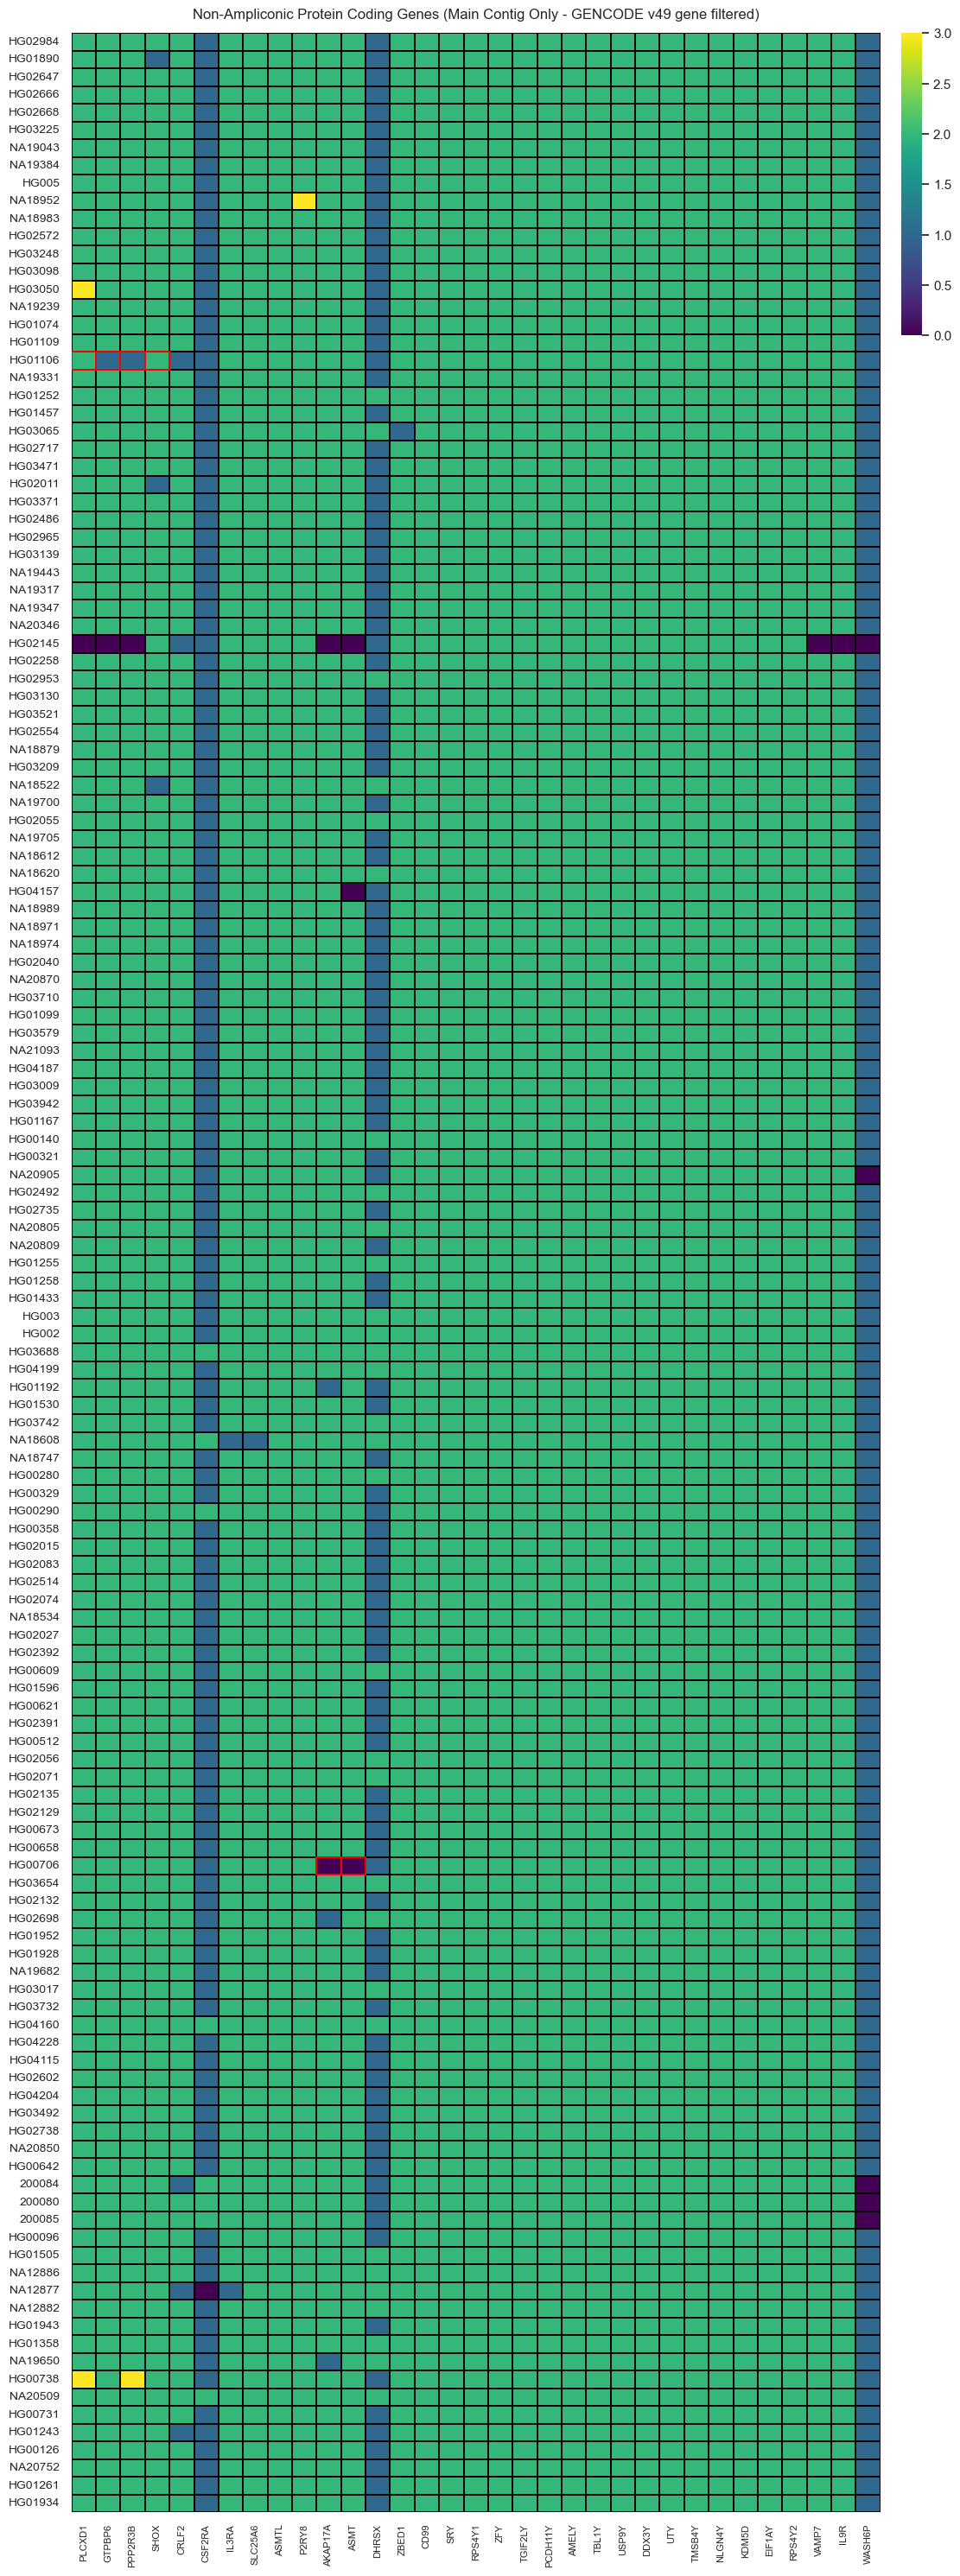

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

df = uniqProGenes

gene_order = consensus_order_df.sort_values("mean_rank")["GeneName"].tolist()
gene_order_in_df = [g for g in gene_order if g in df.columns]
extras = [g for g in df.columns if g not in set(gene_order_in_df)]
df_plot = df[gene_order_in_df + extras]

mask_plot = nonprimary_mask.loc[df_plot.index, df_plot.columns]

fig_w = max(12, 0.18 * df_plot.shape[1])
fig_h = max(5, 0.25 * df_plot.shape[0])

fig = plt.figure(figsize=(fig_w, fig_h))
ax = fig.add_axes([0.10, 0.10, 0.78, 0.82])
cax = fig.add_axes([0.90, 0.82, 0.02, 0.10])

hm = sns.heatmap(
    df_plot,
    ax=ax,
    cmap="viridis",
    linewidths=0.2,
    square=False,
    cbar=True,
    cbar_ax=cax,
    linecolor="black",
)

lw = 1.4  
for i in range(mask_plot.shape[0]):       
    for j in range(mask_plot.shape[1]):   
        if mask_plot.iat[i, j]:
            ax.add_patch(Rectangle((j, i), 1, 1, fill=False, edgecolor="red", linewidth=lw))
# --------------------------------------------

ax.set_title("Non-Ampliconic Protein Coding Genes (Main Contig Only - GENCODE v49 gene filtered)", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

fig.savefig("/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/uniqProCodeGenes_heatmap.03102026.jpeg",
            dpi=300, bbox_inches="tight")
fig.savefig("/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/uniqProCodeGenes_heatmap.03102026.pdf",
            bbox_inches="tight")

plt.show()


## Compare just counts

In [46]:
compDF1 = pd.DataFrame(data=compList, columns=['Sample','Contig', 'Biotype','Total','Caller'])
compDF = compDF1[~compDF1['Contig'].str.contains("_random", regex=True)].copy()

/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_5747/1143129512.py:38: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_table(
/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_5747/1143129512.py:38: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sub.pivot_table(


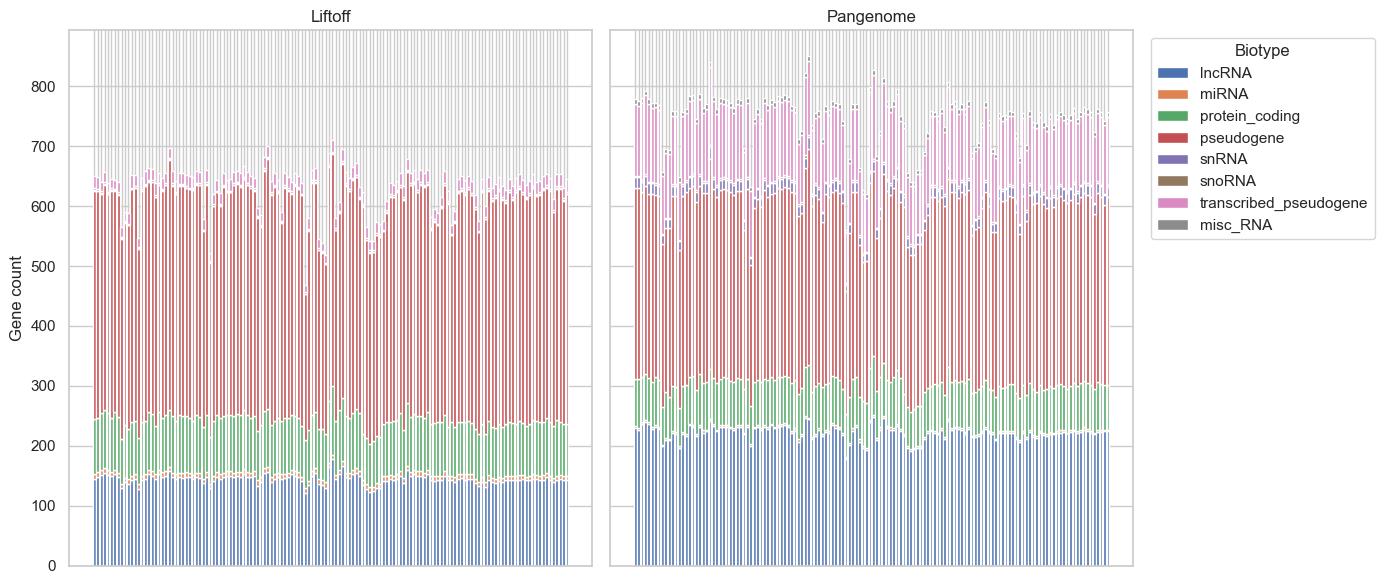

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
sns.set(style="whitegrid")
plotDF1 = (
    compDF
    .groupby(["Sample", "Caller", "Biotype"], as_index=False)["Total"]
    .sum()
)

plotDF = plotDF1.copy() 

sample_order = [s for s in phylogeneticOrder if s in set(plotDF["Sample"])]
sample_order += [s for s in plotDF["Sample"].unique() if s not in set(sample_order)]

plotDF["Sample"] = pd.Categorical(plotDF["Sample"], categories=sample_order, ordered=True)

callers = plotDF["Caller"].unique()
biotypes = plotDF["Biotype"].unique()

fig, axes = plt.subplots(
    1, len(callers),
    figsize=(7 * len(callers), 6),
    sharey=True
)

if len(callers) == 1:
    axes = [axes]

for ax, caller in zip(axes, callers):

    sub = plotDF[plotDF["Caller"] == caller]

    wide = (
        sub.pivot_table(
            index="Sample",
            columns="Biotype",
            values="Total",
            aggfunc="sum",
            fill_value=0
        )
        .reindex(columns=biotypes)
        .reindex(sample_order)  
    )

    bottom = None
    for bt in wide.columns:
        ax.bar(
            wide.index.astype(str),  
            wide[bt].values,
            bottom=bottom,
            label=bt
        )
        bottom = wide[bt].values if bottom is None else bottom + wide[bt].values

    ax.set_title(caller)
    ax.set_xlabel("")
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)  

axes[0].set_ylabel("Gene count")
axes[-1].legend(
    title="Biotype",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
fig.savefig("/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/GeneAnnotationComparison_Barplots.03102026.jpeg",
            dpi=300, bbox_inches="tight")
fig.savefig("/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/GeneAnnotationComparison_Barplots.03102026.pdf",
            bbox_inches="tight")
plt.show()


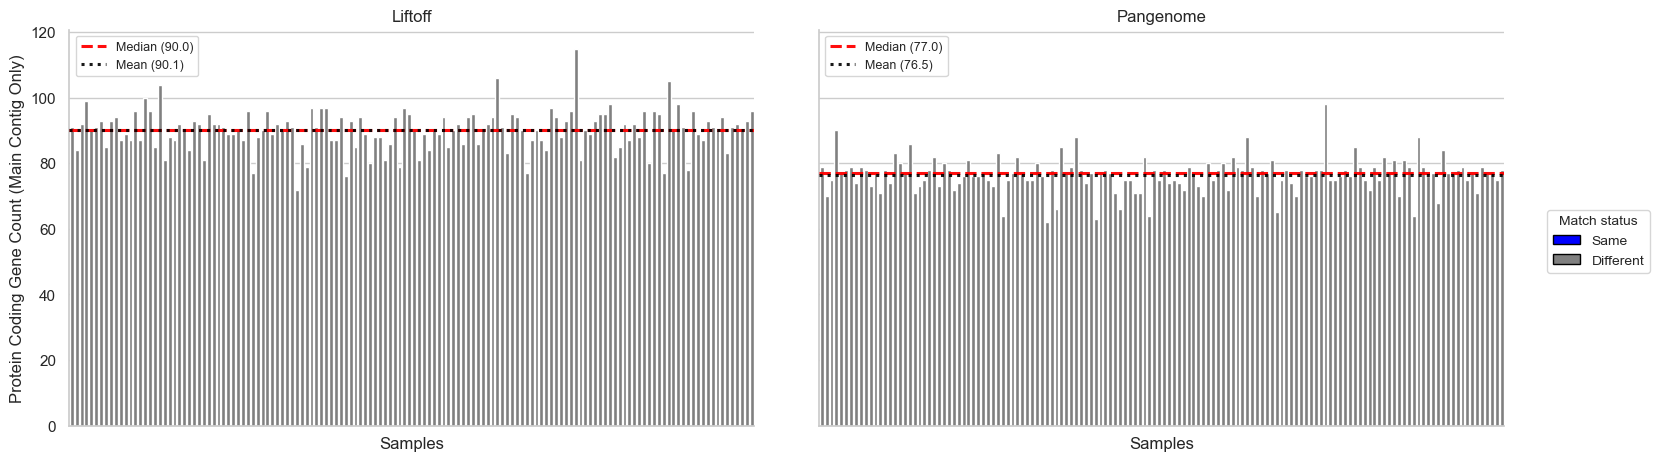

In [48]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

pc_df = compDF[compDF["Biotype"] == "protein_coding"].copy()

wide = (pc_df.pivot_table(index="Sample", columns="Caller", values="Total",
                       aggfunc="sum", fill_value=0).reset_index())

pivot_df = (
    pc_df
    .pivot_table(
        index="Sample",
        columns="Caller",
        values="Total",
        aggfunc="sum",
        fill_value=0
    )
    .reset_index()
)

sns.set(style="whitegrid")

wide = pc_df.pivot_table(index="Sample", columns="Caller", values="Total", aggfunc="first")
both_present = wide.notna().all(axis=1)
same_value = wide.apply(lambda r: r.dropna().nunique() == 1, axis=1)
match_flag = (both_present & same_value)

status_map = match_flag.map({True: "Same", False: "Different"})
pc_df2 = pc_df.copy()
pc_df2["MatchStatus"] = pc_df2["Sample"].map(status_map).fillna("Different")

palette = {"Same": "blue", "Different": "grey"}

g = sns.catplot(
    data=pc_df2,
    x="Sample",
    y="Total",
    col="Caller",
    kind="bar",
    hue="MatchStatus",
    palette=palette,
    dodge=False,
    sharey=True,
    height=5,
    aspect=1.8,
    errorbar=None,
    legend=False,   
)

g.set_axis_labels("Samples", "Protein Coding Gene Count (Main Contig Only)")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    caller = ax.get_title()
    sub = pc_df2.loc[pc_df2["Caller"] == caller, "Total"].dropna()
    if sub.empty:
        continue

    mean_val = float(sub.mean())
    med_val  = float(sub.median())

    median_line = ax.axhline(
        med_val, linestyle="--", linewidth=2.2, color="red", alpha=0.95, zorder=10
    )
    mean_line = ax.axhline(
        mean_val, linestyle=":", linewidth=2.2, color="black", alpha=0.90, zorder=11
    )

    ax.set_xticklabels([])
    ax.tick_params(axis="x", length=0)

    ax.legend(
        handles=[median_line, mean_line],
        labels=[f"Median ({med_val:.1f})", f"Mean ({mean_val:.1f})"],
        loc="upper left",
        frameon=True,
        fontsize=9,
        title="",
    )

status_handles = [
    Patch(facecolor=palette["Same"], edgecolor="black", label="Same"),
    Patch(facecolor=palette["Different"], edgecolor="black", label="Different"),
]

g.fig.subplots_adjust(right=0.84)

g.fig.legend(
    handles=status_handles,
    loc="center left",
    bbox_to_anchor=(0.86, 0.5), 
    frameon=True,
    title="Match status",
    fontsize=10,
    title_fontsize=10,
)

#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/Genes/GeneAnnotation_ProteinCoding_Barplots.02192026.jpeg",
#            dpi=300, bbox_inches="tight")
#plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/Genes/GeneAnnotation_ProteinCoding_Barplots.02192026.pdf",
#            bbox_inches="tight")
plt.show()


/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_5747/4219268940.py:18: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = df.pivot_table(index=["Biotype", "Sample"], columns="Caller", values="Total", aggfunc="sum")


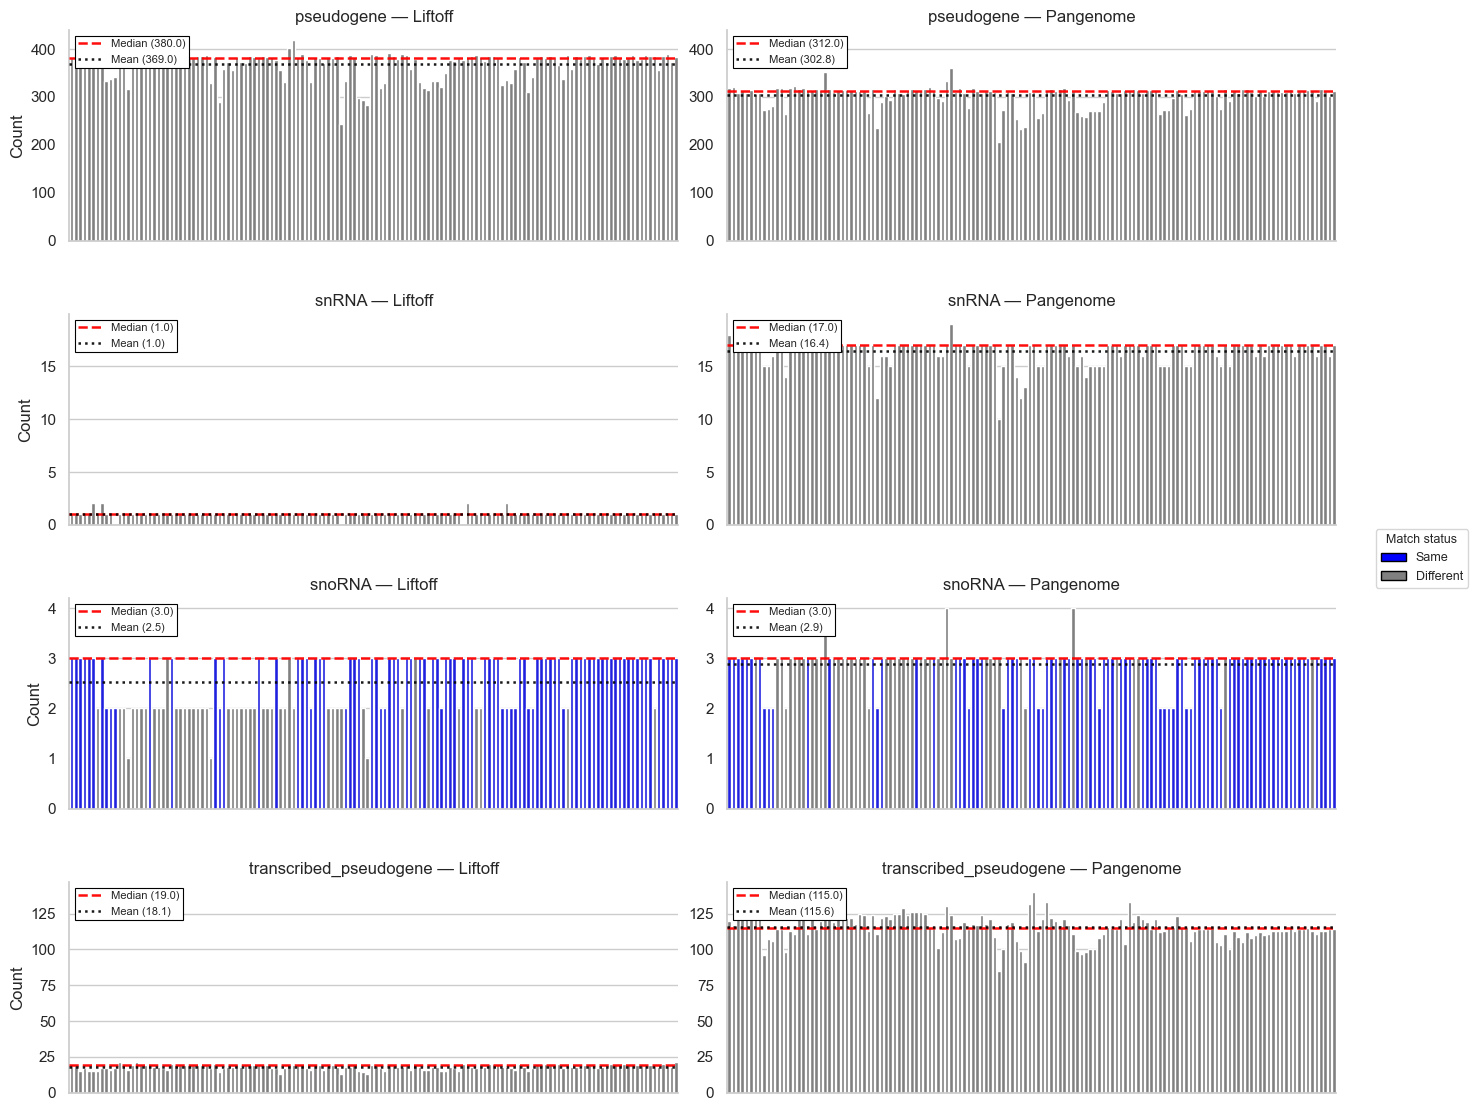

In [57]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sns.set(style="whitegrid")

biotypes_keep = ['pseudogene','transcribed_pseudogene','snRNA','snoRNA',]
df = compDF[compDF["Biotype"].isin(biotypes_keep)].copy()

df["Sample"] = pd.Categorical(df["Sample"], categories=phylogeneticOrder, ordered=True)
df["Sample"] = df["Sample"].cat.remove_unused_categories()
df = df.sort_values(["Biotype", "Sample", "Caller"])

wide = df.pivot_table(index=["Biotype", "Sample"], columns="Caller", values="Total", aggfunc="sum")
both_present = wide.notna().all(axis=1)
same_value = wide.apply(lambda r: r.dropna().nunique() == 1, axis=1)
match_flag = (both_present & same_value)

status_map = match_flag.map({True: "Same", False: "Different"})
df["MatchStatus"] = df.set_index(["Biotype", "Sample"]).index.map(status_map).fillna("Different")

palette = {"Same": "blue", "Different": "grey"}

caller_order = ["Liftoff", "Pangenome"]
caller_order = [c for c in caller_order if c in df["Caller"].unique()]

g = sns.catplot(
    data=df,
    x="Sample",
    y="Total",
    row="Biotype",
    col="Caller",
    col_order=caller_order if caller_order else None,
    kind="bar",
    hue="MatchStatus",
    palette=palette,
    dodge=False,
    sharey=False,     
    height=3.0,
    aspect=2.8,
    errorbar=None,
    legend=False,
)

g.set_axis_labels("", "Count")
g.set_titles("{row_name} — {col_name}")

for (biotype, caller), ax in g.axes_dict.items():
    sub = df[(df["Biotype"] == biotype) & (df["Caller"] == caller)]["Total"].dropna()
    if sub.empty:
        continue

    mean_val = float(sub.mean())
    med_val  = float(sub.median())

    median_line = ax.axhline(med_val, linestyle="--", linewidth=1.8, color="red",   alpha=0.95, zorder=10)
    mean_line   = ax.axhline(mean_val, linestyle=":",  linewidth=1.8, color="black", alpha=0.90, zorder=11)

    ax.set_xticklabels([])
    ax.tick_params(axis="x", length=0)

    leg = ax.legend(
        handles=[median_line, mean_line],
        labels=[f"Median ({med_val:.1f})", f"Mean ({mean_val:.1f})"],
        loc="upper left",
        frameon=True,
        fontsize=8,
        title="",
        borderpad=0.3,
        handlelength=2.2,
        fancybox=False,
        framealpha=1.0,   
    )
    leg.set_zorder(10_000)
    frame = leg.get_frame()
    frame.set_facecolor("white")
    frame.set_edgecolor("black")
    frame.set_linewidth(0.8)

pad_frac = 0.05  
for biotype in biotypes_keep:
    if biotype not in df["Biotype"].unique():
        continue

    row_max = df.loc[df["Biotype"] == biotype, "Total"].max()
    if pd.isna(row_max):
        continue

    ymax = row_max * (1 + pad_frac)

    for caller in caller_order:
        ax = g.axes_dict.get((biotype, caller))
        if ax is not None:
            ax.set_ylim(0, ymax)

status_handles = [
    Patch(facecolor=palette["Same"], edgecolor="black", label="Same"),
    Patch(facecolor=palette["Different"], edgecolor="black", label="Different"),
]
g.fig.subplots_adjust(right=0.80, hspace=0.35, wspace=0.08)

g.fig.legend(
    handles=status_handles,
    loc="center left",
    bbox_to_anchor=(0.82, 0.5), 
    frameon=True,
    title="Match status",
    fontsize=9,
    title_fontsize=9,
)

g.fig.subplots_adjust(top=0.94)
g.fig.savefig(
    "/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/GeneAnnotation_Biotypes2_Barplots-2.03102026.jpeg",
    dpi=300, bbox_inches="tight"
)
g.fig.savefig(
    "/LeeLab/HPRC/chromosomeY/Figures/Genes/FInal/GeneAnnotation_Biotypes_Barplots-2.03102026.pdf",
    bbox_inches="tight"
)

plt.show()
